## Analyzing Completed Simulations
Dan Chen, Summer 2026

### Investigate a specific simulation run & plot its orbital evolution

In [2]:
# === IMPORTS ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

from astropy import units as u
from pathlib import Path
from time import time
from collections import defaultdict
import seaborn as sns
import pickle as pkl

import mmr_id
import rebound_sims as reb_sims

import warnings
warnings.filterwarnings('ignore')
def plot_prettier(dpi=150, fontsize=8, usetex=False): 
    '''
    Make plots look nicer compared to Matplotlib defaults
    Parameters: 
        dpi - int, "dots per inch" - controls resolution of PNG images that are produced
                by Matplotlib
        fontsize - int, font size to use overall
        usetex - bool, whether to use LaTeX to render fonds of axes labels 
                use False if you don't have LaTeX installed on your system
    '''
    plt.rcParams['figure.dpi']= dpi
    plt.rc("savefig", dpi=dpi)
    plt.rc('font', size=fontsize)
    plt.rc('xtick', direction='in') 
    plt.rc('ytick', direction='in')
    plt.rc('xtick.major', pad=5) 
    plt.rc('xtick.minor', pad=5)
    plt.rc('ytick.major', pad=5) 
    plt.rc('ytick.minor', pad=5)
    plt.rc('lines', dotted_pattern = [2., 2.])
    if usetex:
        plt.rc('text', usetex=usetex)
    else:
        plt.rcParams['mathtext.fontset'] = 'cm'
        plt.rcParams['font.family'] = 'serif'
        plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']

plot_prettier()

# === UNIT CONVERSIONS ===
AU = u.AU.to(u.cm)    
G = 4*np.pi**2 # in yr, AU, Msun
Msun = u.Msun.to(u.g) 
yr = u.yr.to(u.s)    
r_earth = u.earthRad.to(u.AU)
m_earth = u.Mearth.to(u.Msun)
r_sun = u.Rsun.to(u.AU) 

Dataset 7, Sim 27
num_pl: 3, num_em: 0, num_ptsml: 0
Sigma_1au: 4885 g/cm^2, h_1au: 0.029


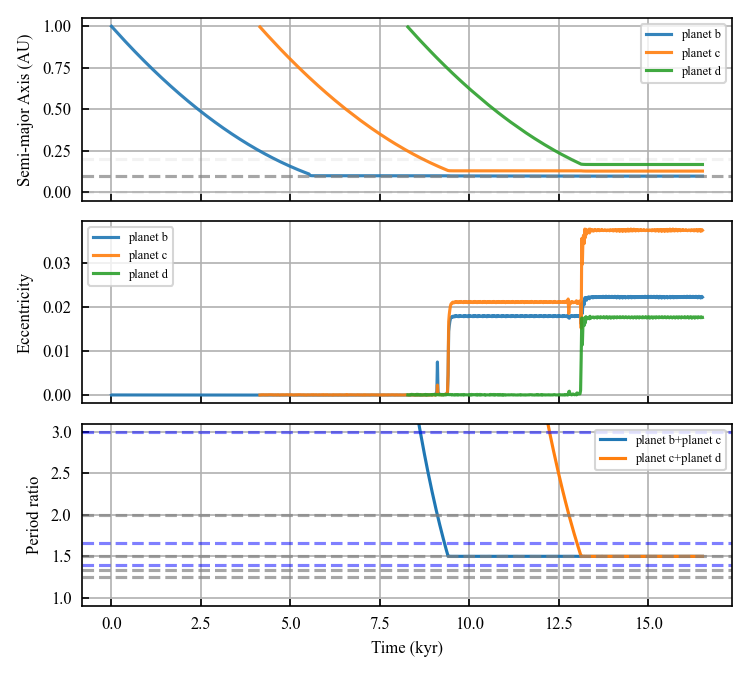

In [7]:
%matplotlib widget

def plot_system(saved_sim, elements, num_pl, num_em, num_ptsml, t_units='kyr'):
    '''
    Takes dataframes for planets and plots a, e, and P ratios over time.
    '''
    
    # Function to plot collision markers
    def plot_end_marker(ax, t, y, **kwargs):
        y = np.asarray(y)

        # Find valid entries
        valid = np.isfinite(y)

        # Only plot marker if the object disappears before the end
        if np.any(valid) and not valid[-1]:
            last_idx = np.where(valid)[0][-1]

            ax.plot(
                t[last_idx],
                y[last_idx],
                marker='x',
                linestyle='None',
                **kwargs
            )
    
    # could also try plotting log
    sim_data, metadata = saved_sim
    rock_names = list(sim_data.keys())
    times = sim_data[rock_names[0]]['time']
    
    fig, axs = plt.subplots(len(elements), 1, sharex=True)
    fig.set_figwidth(5)
    fig.set_figheight(1.5*len(elements))

    time_factor = {'yr': 1, 'kyr': 1e3, 'Myr': 1e6}[t_units]
    pl_style = {'alpha': 0.9}
    em_style = {'c': 'navy', 'alpha': 0.5, 'lw': 0.5}
    ptsml_style = {'c': 'k', 'alpha': 0.2, 'lw': 0.2}

    for i, ax in enumerate(axs):
        if elements[i] == 'a':
            for i in range(num_pl):
                name = rock_names[i]
                ax.plot(times/time_factor, sim_data[name]["a"], **pl_style, label=name)
            
         # Another loop to prevent color confusion
            for i in range(num_pl):
                name = rock_names[i]
                plot_end_marker(ax, times/time_factor, sim_data[name]["a"], c=f'C{i}', ms=5, mew=2.5)

            for i in range(0, num_em, 1):
                name = rock_names[i+num_pl]
                ax.plot(times/time_factor, sim_data[name]["a"], **em_style)
                plot_end_marker(ax, times/time_factor, sim_data[name]["a"], color='r', ms=2, mew=1, alpha=0.7)
            
            for i in range(0, len(rock_names)-num_pl-num_em, 1): # don't use num_ptsml as it doesn't include replenished ptsmls
                name = rock_names[i+num_pl+num_em]
                ax.plot(times/time_factor, sim_data[name]["a"], **ptsml_style)
                plot_end_marker(ax, times/time_factor, sim_data[name]["a"], color='r', ms=1, mew=0.5, alpha=0.6)
            
            # Plot ide location & width
            try:
                ax.axhline(metadata["ide_position"], color='gray', ls='--', alpha=0.7)
                ax.axhline(metadata["ide_position"] - metadata["ide_width"], color='gray', ls='--', alpha=0.1)
                ax.axhline(metadata["ide_position"] + metadata["ide_width"], color='gray', ls='--', alpha=0.1)
            except:
                pass
            
            ax.set_ylabel("Semi-major Axis (AU)")
            # ax.set_ylim(-0.1,1.15)
            
        elif elements[i] == "e":
            for i in range(num_pl):
                name = rock_names[i]
                ax.plot(times/time_factor, sim_data[name]["e"], **pl_style, label=name)
            
         # Another loop to prevent color confusion
            for i in range(num_pl):
                name = rock_names[i]
                plot_end_marker(ax, times/time_factor, sim_data[name]["e"], c=f'C{i}', ms=5, mew=2.5)

            for i in range(0, num_em, 1):
                name = rock_names[i+num_pl]
                ax.plot(times/time_factor, sim_data[name]["e"], **em_style)
                plot_end_marker(ax, times/time_factor, sim_data[name]["e"], color='r', ms=2, mew=1, alpha=0.7)
            
            for i in range(0, len(rock_names)-num_pl-num_em, 1): # don't use num_ptsml as it doesn't include replenished ptsmls
                name = rock_names[i+num_pl+num_em]
                ax.plot(times/time_factor, sim_data[name]["e"], **ptsml_style)
                plot_end_marker(ax, times/time_factor, sim_data[name]["e"], color='r', ms=1, mew=0.5, alpha=0.6)
                    
            ax.set_ylabel("Eccentricity")
            
        elif elements[i] == 'P_ratio':
            for i in range(num_pl):
                name = rock_names[i]
                if i < num_pl-1:
                    ax.plot(times/time_factor, sim_data[rock_names[i+1]]["P"]/sim_data[name]["P"], label=f"{name}+{rock_names[i+1]}")
            
            # Add horizontal lines for resonances
            first_res = [2/1, 3/2, 4/3, 5/4]
            second_res = [3/1, 5/3, 7/5]
            third_res = [4/1, 5/2, 7/4, 8/5]
    
            for r in first_res:
                ax.axhline(r, color='gray', ls='--', alpha=0.7)
            for r in second_res:
                ax.axhline(r, color='blue', ls='--', alpha=0.5)
            # for r in third_res:
            #     ax3.axhline(r, color='red', ls='--', alpha=0.5)
            
            ax.set_ylabel("Period ratio")
            ax.set_ylim(0.9,3.1)

        elif elements[i] == "inc":
            for i in range(num_pl):
                name = rock_names[i]
                ax.plot(times/time_factor, sim_data[name]["inc"], **pl_style, label=name)
            
         # Another loop to prevent color confusion
            for i in range(num_pl):
                name = rock_names[i]
                plot_end_marker(ax, times/time_factor, sim_data[name]["inc"], c=f'C{i}', ms=5, mew=2.5)

            for i in range(0, num_em, 1):
                name = rock_names[i+num_pl]
                ax.plot(times/time_factor, sim_data[name]["inc"], **em_style)
                plot_end_marker(ax, times/time_factor, sim_data[name]["inc"], color='r', ms=2, mew=1, alpha=0.7)
            
            for i in range(0, len(rock_names)-num_pl-num_em, 1): # don't use num_ptsml as it doesn't include replenished ptsmls
                name = rock_names[i+num_pl+num_em]
                ax.plot(times/time_factor, sim_data[name]["inc"], **ptsml_style)
                plot_end_marker(ax, times/time_factor, sim_data[name]["inc"], color='r', ms=1, mew=0.5, alpha=0.6)
                    
            ax.set_ylabel("Inclination")
        
        elif elements[i] == "pomega":
            for i in range(num_pl):
                name = rock_names[i]
                ax.plot(times/time_factor, sim_data[name]["pomega"], **pl_style, label=name)
            
         # Another loop to prevent color confusion
            for i in range(num_pl):
                name = rock_names[i]
                plot_end_marker(ax, times/time_factor, sim_data[name]["pomega"], c=f'C{i}', ms=5, mew=2.5)

            for i in range(0, num_em, 1):
                name = rock_names[i+num_pl]
                ax.plot(times/time_factor, sim_data[name]["pomega"], **em_style)
                plot_end_marker(ax, times/time_factor, sim_data[name]["pomega"], color='r', ms=2, mew=1, alpha=0.7)
            
            for i in range(0, len(rock_names)-num_pl-num_em, 1): # don't use num_ptsml as it doesn't include replenished ptsmls
                name = rock_names[i+num_pl+num_em]
                ax.plot(times/time_factor, sim_data[name]["pomega"], **ptsml_style)
                plot_end_marker(ax, times/time_factor, sim_data[name]["pomega"], color='r', ms=1, mew=0.5, alpha=0.6)
                    
            ax.set_ylabel(r"$\varpi$")
            
    axs[-1].set_xlabel("Time (kyr)")
    for ax in axs:
        ax.legend(fontsize=6)
        ax.grid(True)

    fig.subplots_adjust(hspace=0)

    # plt.suptitle("Orbital Evolution")
    plt.tight_layout(); plt.show()
    # plt.savefig("orbital_evo.svg", bbox_inches="tight")

dataset_id = 7
sim_id = 27

for sim_id in range(sim_id, sim_id+1):
    base_dir = Path.cwd()
    file_path = base_dir.parent / f"sim_results/dataset{dataset_id}" / f"sim{sim_id}.h5"

    try:
        saved_sim = reb_sims.load_simulation_run(file_path)
    except FileNotFoundError:
        # print(f"Sim {sim_id} not found")
        continue

    sim_data, metadata = saved_sim
    m_star = metadata['m_star'] 
    rock_names = list(sim_data.keys())
    rocks = {p: sim_data[p] for p in rock_names}
    num_pl, num_em, num_ptsml = metadata['num_pl'], metadata['num_em'], metadata['num_ptsml']

    print(f"Dataset {dataset_id}, Sim {sim_id}")    
    print(f"num_pl: {metadata['num_pl']}, num_em: {metadata['num_em']}, num_ptsml: {metadata['num_ptsml']}") 
    print(f"Sigma_1au: {metadata['Sigma_1au']:.0f} g/cm^2, h_1au: {metadata['h_1au']:.3f}") 
    plot_system(saved_sim, ['a', 'e', 'P_ratio'], num_pl, num_em, num_ptsml)

### Check for resonance between planets

In [125]:
# Get planet outcomes for all sims in one dataset
not_found = []

def get_planet_outcomes(dataset_id, num_sims, amp_threshold=90):
    rows = []
    
    for sim_id in range(num_sims):
        base_dir = Path.cwd()
        file_path = base_dir.parent / f"sim_results/dataset{dataset_id}" / f"sim{sim_id}.h5"
        
        try:
            saved_sim = reb_sims.load_simulation_run(file_path)
        except FileNotFoundError:
            not_found.append(sim_id)
            continue

        sim_data, metadata = saved_sim
        
        # Check planet survival
        alive_planets = []
        for name in ['planet b', 'planet c', 'planet d'][:metadata['num_pl']]:
            if not np.isnan(sim_data[name]['a'].iloc[-1]):
                alive_planets.append(name)

        # Check both pairs if all planets are alive
        if len(alive_planets) == 3:
            c = alive_planets[1]; d = alive_planets[2]
            
            # Get P_ratios by direct division
            true_outer_P_ratio = sim_data[d]['P'].iloc[-1]/sim_data[c]['P'].iloc[-1]
            
            # Check Delta (find p, q such that Delta is closest to 0)
            outer_best = mmr_id.find_best_twoBR_pq(metadata['m_star'], sim_data[c], sim_data[d])
            outer_P_ratio = outer_best[0]/outer_best[1]
            outer_Delta = true_outer_P_ratio/outer_P_ratio - 1
            
            # Check libration of 2BR angle
            outer_librates = (mmr_id.check_resonance(metadata['m_star'], sim_data[c], sim_data[d], amp_threshold=amp_threshold) != (0,0))
        
        else:
            outer_P_ratio = np.nan
            true_outer_P_ratio = np.nan
            outer_Delta = np.nan
            outer_librates = np.nan
        
        # Check ratio of remaining pair, call it inner pair
        if len(alive_planets) >=2:
            b = alive_planets[0]; c = alive_planets[1] # this will be the right pair regardless
                
            # Get P_ratios by direct division
            true_inner_P_ratio = sim_data[c]['P'].iloc[-1]/sim_data[b]['P'].iloc[-1]
                
            # Check Delta (find p, q such that Delta is closest to 0)
            inner_best = mmr_id.find_best_twoBR_pq(metadata['m_star'], sim_data[b], sim_data[c])
            inner_P_ratio = inner_best[0]/inner_best[1]
            inner_Delta = true_inner_P_ratio/inner_P_ratio - 1
            
            # Check libration of 2BR angle
            inner_librates = (mmr_id.check_resonance(metadata['m_star'], sim_data[b], sim_data[c], amp_threshold=amp_threshold) != (0,0))

        else:
            inner_P_ratio = np.nan
            true_inner_P_ratio = np.nan
            inner_Delta = np.nan
            inner_librates = np.nan
        
        if len(alive_planets) >= 1:
            alpha = metadata['alpha']
            m_pl = metadata['m_vals'][0] * m_earth
            r = metadata['ide_position']
            h = metadata['h_1au']*r**metadata['beta']
            tau_wave = (1/m_pl) * (1/(metadata['Sigma_1au']*r**metadata['beta'] * r**2)) * (h/r)**4 / (2*np.pi/np.sqrt(r**3))
            tau_a = (2*tau_wave)/(2.7+1.1*alpha) * (h/r)**-2
        else:
            tau_a = np.nan

        # Create df to store data
        Sigma_1au = metadata['Sigma_1au']
        h_1au = metadata['h_1au']
        
        rows.append({
            "Sigma_1au": Sigma_1au,
            "h_1au": h_1au,
            "alive_planets": alive_planets,
            "inner_P_ratio": inner_P_ratio,
            "outer_P_ratio": outer_P_ratio,
            "true_inner_P_ratio": round(true_inner_P_ratio, 3),
            "true_outer_P_ratio": round(true_outer_P_ratio, 3),
            "inner_P_Delta (%)": round(inner_Delta*100, 1),
            "outer_P_Delta (%)": round(outer_Delta*100, 1),
            "inner_librates": inner_librates,
            "outer_librates": outer_librates,
            "pl_survived": len(alive_planets),
            "tau_a (kyr)": tau_a/1000
        })
        
    outcomes = pd.DataFrame(rows)
    outcomes.index.name = 'sim_id'
    return outcomes

planet_outcomes = get_planet_outcomes(dataset_id=5, num_sims=100, amp_threshold=90)
print(not_found)

[]


In [ ]:
from fractions import Fraction

def plot_param_map(outcomes, value_col, label, cmap='inferno', vmin=None, vmax=None, exp=False, log_cmap=False, show_libration=False, show_Delta=False, black_threshold=0.5):
    x_vals = np.sort(outcomes["Sigma_1au"].unique())
    y_vals = np.sort(outcomes["h_1au"].unique())
        
    # Grid
    grid = (
        outcomes
        .pivot(index="Sigma_1au",
               columns="h_1au",
               values=value_col)
        .reindex(index=x_vals,
                 columns=y_vals)
    )

    values = grid.values

    # Libration and Delta grid
    if value_col == "inner_P_ratio":
        if show_libration:
            libration_grid = (
                outcomes
                .pivot(index="Sigma_1au", columns="h_1au", values="inner_librates")
                .reindex(index=x_vals, columns=y_vals)
            )
        else:
            libration_grid = None
        if show_Delta:
            Delta_grid = (
                outcomes
                .pivot(index="Sigma_1au", columns="h_1au", values="inner_P_Delta (%)")
                .reindex(index=x_vals, columns=y_vals)
            )
        else:
            Delta_grid = None
    elif value_col == "outer_P_ratio":
        if show_libration:
            libration_grid = (
                outcomes
                .pivot(index="Sigma_1au", columns="h_1au", values="outer_librates")
                .reindex(index=x_vals, columns=y_vals)
            )
        else:
            libration_grid = None
        if show_Delta:
            Delta_grid = (
                outcomes
                .pivot(index="Sigma_1au", columns="h_1au", values="outer_P_Delta (%)")
                .reindex(index=x_vals, columns=y_vals)
            )
        else:
            Delta_grid = None
    else:
        libration_grid = None
        Delta_grid = None

    # Edges 
    x_edges = np.empty(len(x_vals)+1)
    x_edges[1:-1] = np.sqrt(x_vals[:-1] * x_vals[1:])
    x_edges[0] = x_vals[0]**2 / x_edges[1]
    x_edges[-1] = x_vals[-1]**2 / x_edges[-2]

    y_edges = np.empty(len(y_vals)+1)
    y_edges[1:-1] = np.sqrt(y_vals[:-1] * y_vals[1:])
    y_edges[0] = y_vals[0]**2 / y_edges[1]
    y_edges[-1] = y_vals[-1]**2 / y_edges[-2]
    
    # Plotting
    fig, ax = plt.subplots(figsize=(5,4))
    norm = LogNorm(vmin=vmin, vmax=vmax) if log_cmap else None
    mesh = ax.pcolormesh(
        x_edges,
        y_edges,
        values.T,
        cmap=cmap,
        norm=norm,
        shading="flat",
        vmin=vmin, 
        vmax=vmax
    )

    ax.set_xlabel(r"$\Sigma_{1\,\rm AU}\;(\mathrm{g\,cm^{-2}})$")
    ax.set_ylabel(r"$h_{1\,\rm AU}$")
    
    # Present graph as log
    ax.set_xscale("log")
    ax.set_yscale("log")

    ax.set_xticks(x_vals)
    ax.set_yticks(y_vals)

    ax.set_xticklabels([f"{x:.0f}" for x in x_vals])
    ax.set_yticklabels([f"{y:.3f}" for y in y_vals])

    ax.minorticks_off()

    # Cell text
    for i, x in enumerate(x_vals):
        for j, y in enumerate(y_vals):

            value = values[i, j]
            if np.isnan(value):
                continue

            color = "black"
            if value < black_threshold:
                color = "white"

            if exp:
                value = f"{value:.1e}"
            elif "%" in value_col:
                value = f"{value:.3g}%"
            elif "ratio" in value_col:
                frac = Fraction(value).limit_denominator()
                value = f"{frac.numerator}:{frac.denominator}"
            elif "kyr" in value_col:
                value = f"{round(value)}"
            else:
                value = f"{value:.2g}"
            
            ax.text(
                x, y,
                value,
                ha="center",
                va="center",
                fontsize=6,
                weight='bold',
                color=color
            )

            if libration_grid is not None:
                if libration_grid.values[i, j]:
                    ax.annotate(
                        "L",
                        xy=(x, y),
                        xytext=(0, 10),
                        textcoords="offset points",
                        ha="center",
                        va="top",
                        fontsize=5,
                        color="C2",
                        fontweight="bold"
                    )
                    
            if Delta_grid is not None:
                ax.annotate(
                    rf"$\Delta = {Delta_grid.values[i, j]}$%",
                    xy=(x, y),
                    xytext=(0, -5),
                    textcoords="offset points",
                    ha="center",
                    va="top",
                    fontsize=4,
                    color=color,
                    fontweight="bold"
                )

    cbar = fig.colorbar(mesh, ax=ax)
    cbar.set_label(label)

    plt.tight_layout()
    plt.show()
    
plot_param_map(planet_outcomes, "pl_survived", "Number of planets remaining", cmap='inferno', vmin=1, black_threshold=1.5)
plot_param_map(planet_outcomes, "inner_P_ratio", r"Inner pair period ratio ($P_c/P_b$)", vmin=1, vmax=2, show_libration=True, black_threshold=1.6)
plot_param_map(planet_outcomes, "outer_P_ratio", r"Outer pair period ratio ($P_d/P_c$)", vmin=1, vmax=2, show_libration=True, black_threshold=1.6)
# plot_param_map(planet_outcomes, "tau_a (kyr)", r"$\tau_a$ (kyr)", cmap='coolwarm', log_cmap=True, black_threshold=0)

### Collect data on embryo and planetesimal accretion

In [145]:
def get_collision_log(metadata):
    """Collects collision log and converts to pd.DataFrame for later use.

    Args:
        metadata (dict): Metadata from simulation; typically comes from saved_sim[1].

    Returns:
        pd.DataFrame: collision_df
    """    
    collision_df = pd.DataFrame(metadata["collision_log"])
    collision_df["time"] = (collision_df["time"] / 1000).round(2)
    collision_df = collision_df.rename(columns={"time": "time (kyr)"})
    collision_df = collision_df.sort_values("time (kyr)")
    collision_df["victim mass"] = (collision_df["victim mass"] / m_earth).round(4)
    collision_df = collision_df.rename(columns={"victim mass": "victim mass (m_earth)"})
    return collision_df

def get_particle_fates(metadata):
    fates_df = (pd.Series(metadata["particle_fate"]).rename("outcome"))
    # # Omit alive particles
    # fates_df = fates_df[fates_df != "alive"]  
    fates_df = fates_df.sort_values()
    fates_df = fates_df.to_frame() 
    return fates_df

# collision_df = get_collision_log(metadata)
# fates_df = get_particle_fates(metadata)

In [146]:
def summarize_accretion(collision_df, fates_df, percent=True):
    """Summarizes accretion information.

    Args:
        collision_df (pandas.DataFrame): DataFrame of collision log.
        percent (bool, optional): Whether to show fraction as percentage. 
            Defaults to True.

    Returns:
        pandas.DataFrame: Dataframe containing accretion summary.
    """    
    children = defaultdict(list)

    for _, row in collision_df.iterrows():
        children[row["survivor"]].append(row["victim"])

    def get_all_accreted(body):
        """Returns every particle ultimately accreted by body."""
        accreted = []

        for child in children.get(body, []):
            accreted.append(child)
            accreted.extend(get_all_accreted(child))

        return accreted

    alive_particles = [
        name
        for name, outcome in fates_df["outcome"].items()
        if outcome == "alive"
    ]

    rows = []

    for particle in alive_particles:
        accreted = get_all_accreted(particle)

        n_embryos = sum("embryo" in p for p in accreted)
        n_ptsmls = sum("ptsml" in p for p in accreted)

        rows.append({
            "particle": particle,
            "n_ems": n_embryos,
            "n_ptsmls": n_ptsmls,
            "embryo %": n_embryos / num_em,
            "ptsml %": n_ptsmls / num_ptsml,
        })

    alive_accretion_df = (pd.DataFrame(rows).set_index("particle").sort_index())

    # Keep only particles that actually accreted something
    alive_accretion_df = alive_accretion_df[
        alive_accretion_df["n_ems"] + alive_accretion_df["n_ptsmls"] > 0
    ].sort_values('n_ptsmls', ascending=False) # & sort by ptsmls accreted

    # Remaining unaccreted bodies
    n_alive_ems = num_em - alive_accretion_df["n_ems"].sum()
    n_alive_ptsmls = num_ptsml - alive_accretion_df["n_ptsmls"].sum()

    alive_accretion_df.loc["Survived"] = {
        "n_ems": n_alive_ems,
        "n_ptsmls": n_alive_ptsmls,
        "embryo %": n_alive_ems / num_em,
        "ptsml %": n_alive_ptsmls / num_ptsml,
    }

    if percent:
        # Convert to %
        alive_accretion_df["embryo %"] = (alive_accretion_df["embryo %"]*100).round(2)
        alive_accretion_df["ptsml %"] = (alive_accretion_df["ptsml %"]*100).round(2)

    return alive_accretion_df

# summary = summarize_accretion(collision_df, fates_df)
# summary

In [ ]:
# Get ptsml outcomes for all sims in one dataset
def get_ptsml_outcomes(dataset_id, num_sims):
    rows = []
    
    for sim_id in range(num_sims):
        base_dir = Path.cwd()
        file_path = base_dir.parent / f"sim_results/dataset{dataset_id}" / f"sim{sim_id}.h5"
        
        try:
            saved_sim = reb_sims.load_simulation_run(file_path)
        except FileNotFoundError:
            # print(f"Sim {sim_id} not found")
            continue
        
        metadata = saved_sim[1]
        
        # Get survival fraction
        collision_df = get_collision_log(metadata)
        fates_df = get_particle_fates(metadata)
        summary = summarize_accretion(collision_df, fates_df)
        surv_rate = summary['ptsml %']['Survived']
        
        # Get ejection fraction
        fates_df = get_particle_fates(metadata)
        ejec_rate = fates_df['outcome'].str.contains('ejected').sum()/len(fates_df)

        # Create df to store data
        Sigma_1au = metadata['Sigma_1au']
        h_1au = metadata['h_1au']
        
        rows.append({
            "Sigma_1au": Sigma_1au,
            "h_1au": h_1au,
            "surv_rate (%)": surv_rate,
            "ejec_rate (%)": ejec_rate,
        })
        
    outcomes = pd.DataFrame(rows)
    outcomes.index.name = 'sim_id'
    return outcomes

outcomes = get_ptsml_outcomes(dataset_id=9, num_sims=100)
outcomes

,Sigma_1au,h_1au,surv_rate (%),ejec_rate (%)
sim_id,,,,
0,170.000000,0.01,54.0,0.0
1,283.577091,0.01,61.5,0.0
2,473.035098,0.01,58.0,0.0
3,789.070102,0.01,55.5,0.0
4,1316.248261,0.01,57.5,0.0
...,...,...,...,...
82,2195.634431,0.10,30.0,0.0
83,3662.538973,0.10,40.5,0.0
84,6109.483228,0.10,42.5,0.0


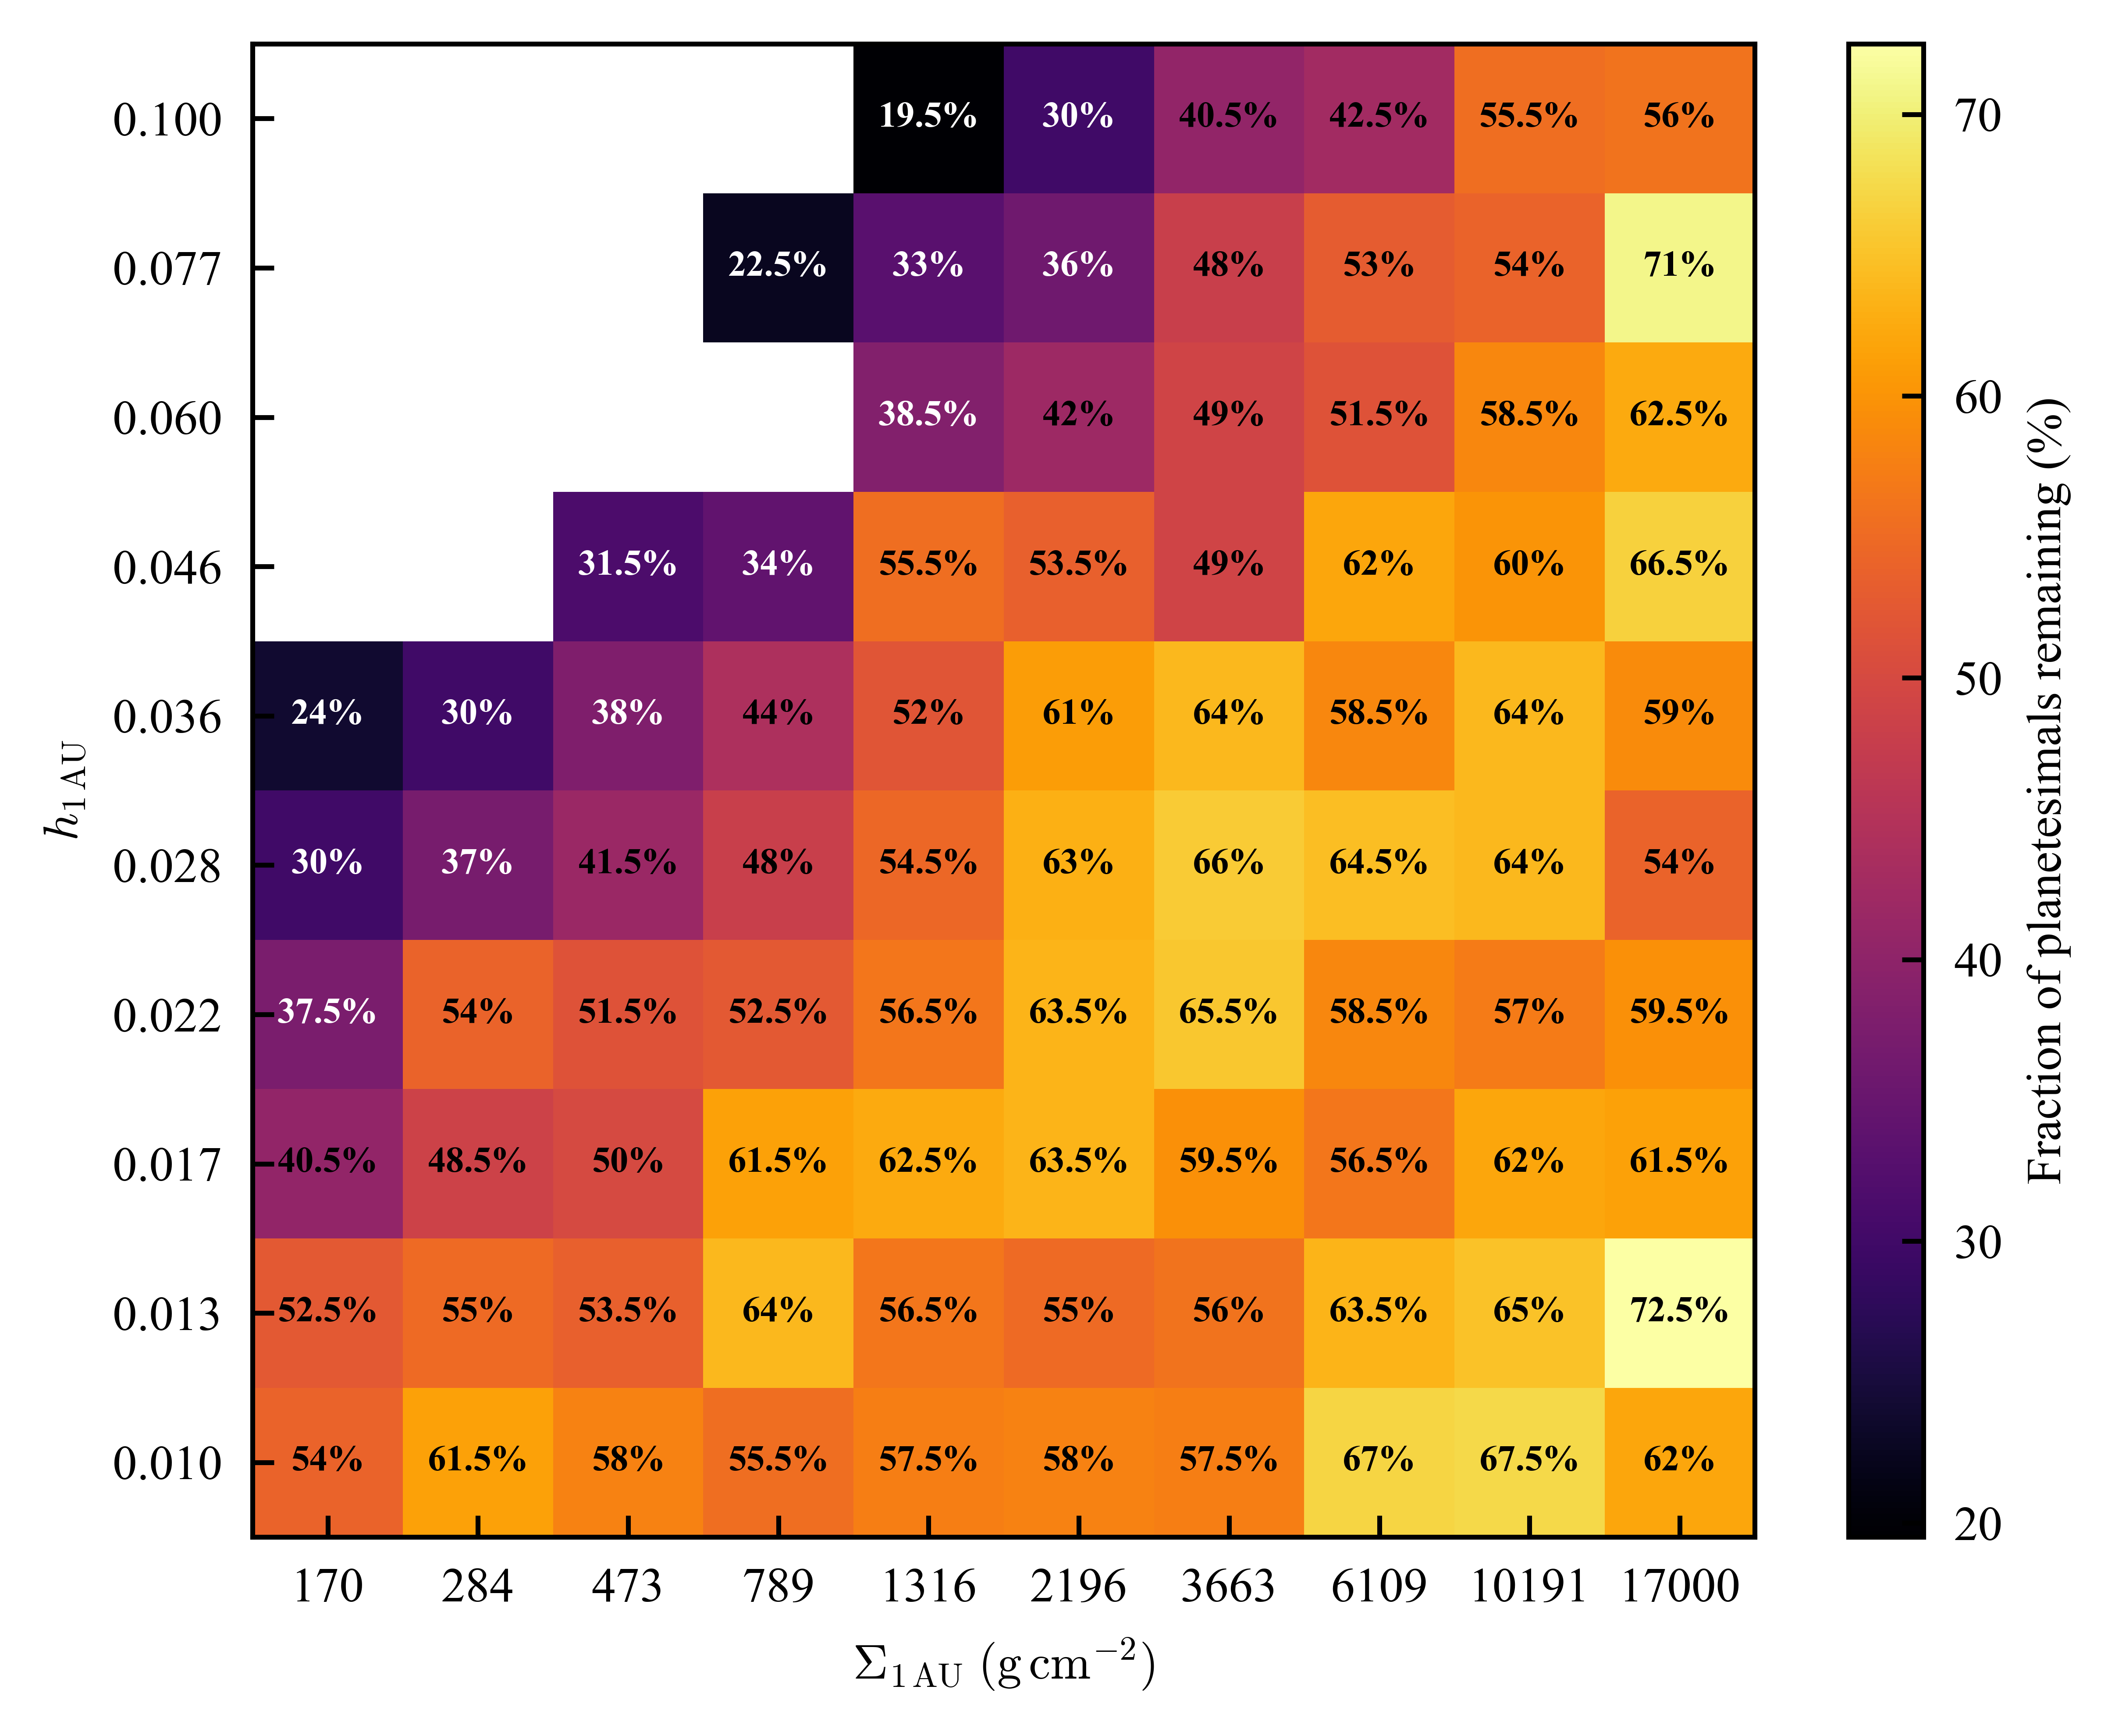

In [ ]:
plot_param_map(outcomes, "surv_rate (%)", "Fraction of planetesimals remaining (%)", black_threshold=40)
# plot_param_map(outcomes, "ejec_rate (%)", "Fraction of planetesimals ejected (%)")

### Plot $a$ vs. $e$ at given snapshots

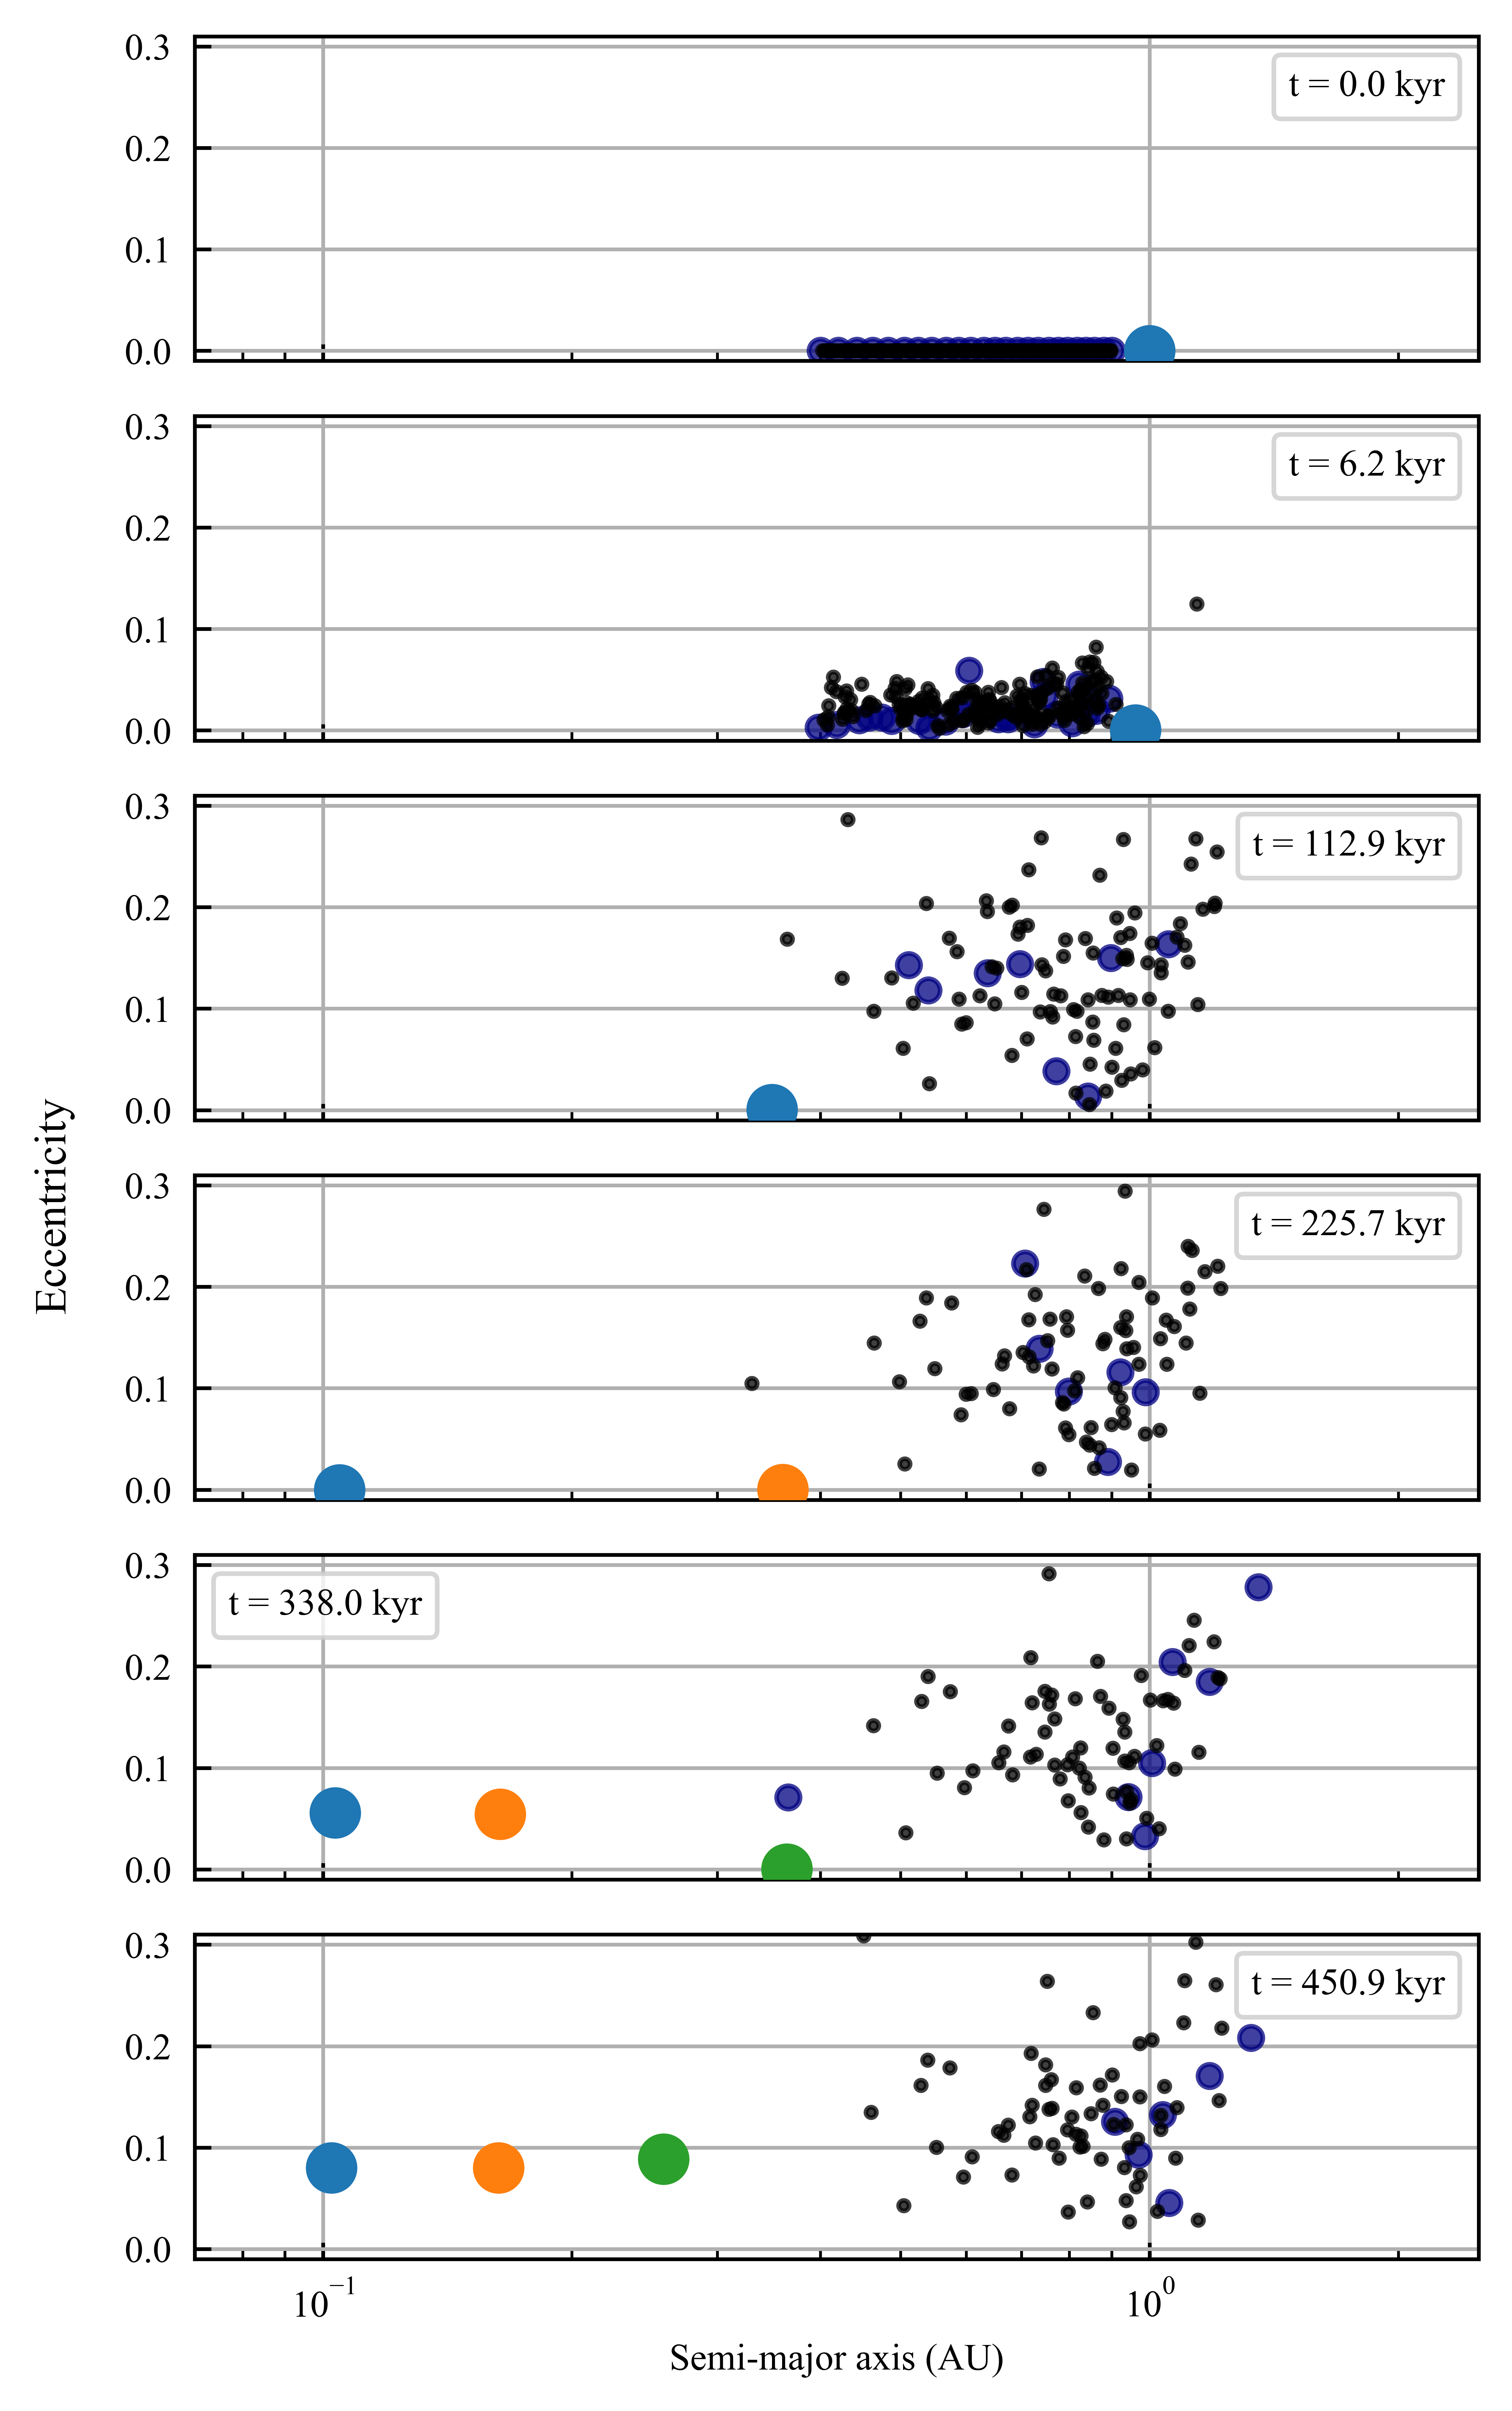

In [ ]:
def plot_ae_snapshot(saved_sim, *snapshot_times):
    """Plot a vs e at a one or more snapshots.
    """

    sim_data = saved_sim[0]

    # Use first body to get time array
    first_name = rock_names[0]
    times = sim_data[first_name]["time"]

    # Get idxs that best match the times given
    snapshot_idxs = np.array([
        np.argmin(np.abs(times - t))
        for t in snapshot_times
    ]) 

    num_plots = len(snapshot_times)
    fig, axs = plt.subplots(num_plots, 1, sharex=True, figsize=(4.5, 1.2 * num_plots))

    for i, ax in enumerate(axs):
        snapshot_idx = snapshot_idxs[i]
        
        # planets
        for j in range(num_pl):
            name = rock_names[j]

            ax.scatter(
                sim_data[name]["a"][snapshot_idx],
                sim_data[name]["e"][snapshot_idx],
                s=100,
                # label=name,
                zorder=3,
                alpha=1
            )

        # embryos
        for j in range(num_em):
            name = rock_names[num_pl + j]

            ax.scatter(
                sim_data[name]["a"][snapshot_idx],
                sim_data[name]["e"][snapshot_idx],
                s=25,
                color='navy',
                alpha=0.75
            )

        # planetesimals
        for j in range(num_ptsml):
            name = rock_names[num_pl + num_em + j]

            ax.scatter(
                sim_data[name]["a"][snapshot_idx],
                sim_data[name]["e"][snapshot_idx],
                s=5,
                c='k',
                alpha=0.75
            )

        if i == num_plots - 1:
            ax.set_xlabel("Semi-major axis (AU)")
        ax.set_ylim(-0.01, 0.31)
        ax.set_xlim(0.07, 2.5)
        ax.set_xscale('log')
        ax.grid(True)
        ax.set_axisbelow(True)

        t = times[snapshot_idx]
        ax.legend(title=f"t = {t/1000:.1f} kyr", title_fontsize=8, labelspacing=0)
        
    fig.supylabel('Eccentricity')
    fig.subplots_adjust(hspace=0)
    # plt.suptitle("Snapshots of Disk Evolution")
    plt.tight_layout()
    plt.show()
    # plt.savefig("disk_snapshots.svg", bbox_inches="tight")
    
end = saved_sim[0]['planet b']['time'].iloc[-1]
plot_ae_snapshot(saved_sim, 0, 6e3, end/5+50, 2*end/5+50, 3*end/5+50, 4*end/5+50)

### Plot libration of the resonance angle $\phi$

True period ratio: 1.2503
p, q: 5, 4
Libration amplitude: 10.2 deg


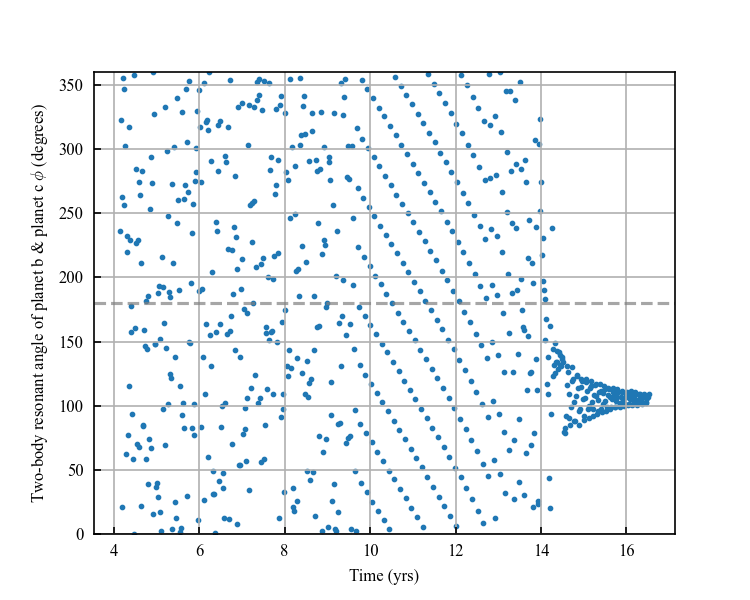

In [143]:
mmr_id.plot_libration(m_star, rocks['planet b'], rocks['planet c'])
# mmr_id.plot_libration(m_star, rocks['planet c'], rocks['planet d'])